# ML Signal Filter, Position Sizing & Equity Curve Analysis

**Base config:** W=55b | HR ≥ 0.80 | SP ≥ 0.70 | NY Session  
**Exit:** Path B2 momentum reversal (K=7b, thr=−5 bps)  

This notebook layers four improvements and compares them on the OOS period:
1. **Baseline** — fixed 35-min hold, flat sizing
2. **+ Path B2 exit** — momentum-reversal dynamic exit
3. **+ SD filter + 10:30 gate** — volatility-band entry filter (Issue #6)
4. **+ ML filter + vol sizing** — logistic regression quality filter, volatility-adjusted position sizing

In [68]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

from src.data_pipeline import load_market_data, convert_index_timezone, add_calendar_features
from src.indicators import add_correlation_metrics, build_volume_analysis_frame
from src.simulation import build_signal_frame

# ── constants ──────────────────────────────────────────────────────────────
WINDOW          = 55
HR_THRESH       = 0.80
SP_THRESH       = 0.70
FIXED_HOLD      = 35      # minutes — baseline
B2_K            = 7       # Path B2 reversal look-back bars
B2_THR_BPS      = -5.0    # Path B2 exit threshold (bps)
MAX_HOLD        = 60      # hard cap (bars)
IS_RATIO        = 0.70    # in-sample fraction (chronological)
TARGET_RISK_BPS = 10.0    # volatility-adjusted sizing target (bps)
FEATURE_COLS    = [
    "hit_ratio", "corr_spearman", "mom_window",
    "rolling_std_nq", "conviction_score",
    "hour_sin", "hour_cos",
]
print("Imports OK")

Imports OK


## 1. Data Loading & Signal Reconstruction

In [69]:
df_raw = load_market_data()
df     = convert_index_timezone(df_raw, "America/New_York")
df     = add_calendar_features(df)

# Correlation metrics (Spearman, hit_ratio, Pearson) — W=55
metrics_df = add_correlation_metrics(df, window=WINDOW)

# Momentum regime direction — same look-back as signal window
metrics_df["mom_window"]  = (
    metrics_df["nq_close"] / metrics_df["nq_close"].shift(WINDOW) - 1
)
metrics_df["regime_dir"] = np.sign(metrics_df["mom_window"]).replace(0, 1)

# Rolling NQ return std — used for SD filter and position sizing
metrics_df["rolling_std_nq"] = (
    metrics_df["nq_ret"].rolling(window=WINDOW).std()
)

# Fixed-hold forward returns for Curve 1 baseline
metrics_df["nq_fwd_35"] = (
    metrics_df["nq_close"].shift(-FIXED_HOLD) / metrics_df["nq_close"] - 1
)

# Volume-weighted features — provides conviction_score
volume_df = build_volume_analysis_frame(metrics_df, window=WINDOW)

print(f"Aligned bars : {len(metrics_df):,}")
print(f"Date range   : {metrics_df.index[0]:%Y-%m-%d} → {metrics_df.index[-1]:%Y-%m-%d}")

Aligned bars : 682,008
Date range   : 2024-03-07 → 2026-03-06


## 2. Baseline Signal Events

Reproduces the signal set from the main notebook (session 09:30, no volatility filter) so that
Curves 1 and 2 are directly comparable to the Section 15 benchmark.

In [70]:
baseline_sig = build_signal_frame(
    metrics_df,
    session_start="09:30",   # original — no 10:30 gate
    hit_ratio_threshold=HR_THRESH,
    spearman_threshold=SP_THRESH,
    std_low_pct=0.0,          # disable SD filter for baseline
    std_high_pct=1.0,
)
baseline_events = baseline_sig[baseline_sig["event_start"]].copy()
baseline_events["conviction_score"] = (
    volume_df["conviction_score"].reindex(baseline_events.index)
)

# IS / OOS split — time-based, shared across all curves
oos_start_ts = baseline_events.index[int(len(baseline_events) * IS_RATIO)]

print(f"Baseline events  : {len(baseline_events)}")
print(f"OOS period starts: {oos_start_ts:%Y-%m-%d %H:%M}")
print(f"  IS events : {(baseline_events.index < oos_start_ts).sum()}")
print(f"  OOS events: {(baseline_events.index >= oos_start_ts).sum()}")

Baseline events  : 466
OOS period starts: 2025-08-29 10:57
  IS events : 326
  OOS events: 140


## 3. Path B2 Exit Simulation

For each signal event, walk forward bar-by-bar and exit at the first bar where the
rolling K-bar NQ return (in trade direction) falls below the reversal threshold.
Hard cap: 60 minutes.

In [71]:
def simulate_path_b2(
    df_full: pd.DataFrame,
    events: pd.DataFrame,
    k: int   = B2_K,
    thr_bps: float = B2_THR_BPS,
    max_hold: int  = MAX_HOLD,
) -> pd.DataFrame:
    """Simulate Path B2 momentum-reversal exits for each event entry."""
    nq   = df_full["nq_close"].values
    idx  = {ts: i for i, ts in enumerate(df_full.index)}
    thr  = thr_bps / 10_000
    rows = []

    for entry_ts, row in events.iterrows():
        direction = row["regime_dir"]
        start = idx.get(entry_ts)
        if start is None:
            rows.append({"entry_ts": entry_ts, "realized_bps": np.nan,
                         "hold_bars": np.nan, "exit_reason": "missing"})
            continue

        entry_price = nq[start]
        exit_bar = start + max_hold
        reason   = "time_cap"

        for t in range(1, max_hold + 1):
            bar = start + t
            if bar >= len(nq):
                exit_bar = bar - 1
                reason   = "end_of_data"
                break
            k_ret = (nq[bar] / nq[max(0, bar - k)] - 1) * direction
            if k_ret < thr:
                exit_bar = bar
                reason   = "b2_reversal"
                break

        realized = (
            (nq[exit_bar] / entry_price - 1) * direction * 10_000
            if exit_bar < len(nq) else np.nan
        )
        rows.append({
            "entry_ts":    entry_ts,
            "realized_bps": realized,
            "hold_bars":   exit_bar - start,
            "exit_reason": reason,
        })

    return pd.DataFrame(rows).set_index("entry_ts")

In [72]:
baseline_b2 = simulate_path_b2(metrics_df, baseline_events)

print("Baseline events — Path B2 exit")
print(f"  n trades  : {baseline_b2['realized_bps'].notna().sum()}")
print(f"  Win rate  : {(baseline_b2['realized_bps'] > 0).mean()*100:.1f}%")
print(f"  Avg bps   : {baseline_b2['realized_bps'].mean():.2f}")
print(f"  Avg hold  : {baseline_b2['hold_bars'].mean():.1f} bars")
print(f"\nExit reasons:")
print(baseline_b2["exit_reason"].value_counts().to_string())

Baseline events — Path B2 exit
  n trades  : 466
  Win rate  : 39.1%
  Avg bps   : 2.49
  Avg hold  : 9.1 bars

Exit reasons:
exit_reason
b2_reversal    463
time_cap         3


## 4. Triple Barrier Labels

For each event:
- **+1** — NQ directional return hits the profit target X before Path B2 fires  
- **−1** — Path B2 momentum reversal fires before profit target  
- **0**  — 60-min time cap reached without either barrier  

X is calibrated as the 60th percentile of winning-trade realized bps in the IS period.

In [73]:
# Calibrate profit target from IS winners
is_mask      = baseline_b2.index < oos_start_ts
is_winners   = baseline_b2.loc[is_mask & (baseline_b2["realized_bps"] > 0), "realized_bps"]
profit_X_bps = float(is_winners.quantile(0.60))
print(f"IS winning trades   : {len(is_winners)}")
print(f"Profit target X (60th pct of IS winners): {profit_X_bps:.2f} bps")


def compute_triple_barrier_labels(
    df_full: pd.DataFrame,
    events: pd.DataFrame,
    profit_x_bps: float,
    k: int   = B2_K,
    rev_thr_bps: float = B2_THR_BPS,
    max_hold: int = MAX_HOLD,
) -> pd.DataFrame:
    """Assign triple-barrier labels to each signal event."""
    nq      = df_full["nq_close"].values
    idx     = {ts: i for i, ts in enumerate(df_full.index)}
    rev_thr = rev_thr_bps / 10_000
    p_thr   = profit_x_bps / 10_000
    rows    = []

    for entry_ts, row in events.iterrows():
        direction = row["regime_dir"]
        start = idx.get(entry_ts)
        if start is None:
            rows.append({"entry_ts": entry_ts, "label": 0, "exit_reason": "missing"})
            continue

        entry_price = nq[start]
        label  = 0
        reason = "time_cap"

        for t in range(1, max_hold + 1):
            bar = start + t
            if bar >= len(nq):
                break
            cum_ret = (nq[bar] / entry_price - 1) * direction
            if cum_ret >= p_thr:
                label  = 1
                reason = "profit_hit"
                break
            k_ret = (nq[bar] / nq[max(0, bar - k)] - 1) * direction
            if k_ret < rev_thr:
                label  = -1
                reason = "reversal"
                break

        rows.append({"entry_ts": entry_ts, "label": label, "exit_reason": reason})

    return pd.DataFrame(rows).set_index("entry_ts")


labels_df = compute_triple_barrier_labels(metrics_df, baseline_events, profit_X_bps)

print("\nLabel distribution (all events):")
counts = labels_df["label"].value_counts().sort_index()
for lbl, cnt in counts.items():
    name = {1: "+1 profit hit", 0: " 0 time cap ", -1: "-1 reversal"}.get(lbl, str(lbl))
    print(f"  {name}: {cnt:4d}  ({cnt/len(labels_df)*100:.1f}%)")

IS winning trades   : 128
Profit target X (60th pct of IS winners): 17.85 bps

Label distribution (all events):
  -1 reversal:  333  (71.5%)
  +1 profit hit:  133  (28.5%)


## 5. Feature Engineering

All features are measured **at the entry bar** — no look-ahead.

| Feature | Description |
|---|---|
| `hit_ratio` | Rolling directional agreement (W=55) at entry |
| `corr_spearman` | Rolling Spearman rank correlation (W=55) at entry |
| `mom_window` | NQ momentum over last 55 bars at entry |
| `rolling_std_nq` | Rolling std of NQ 1-min returns (W=55) — volatility context |
| `conviction_score` | Volume-rank × vw_correlation — high when volume confirms signal |
| `hour_sin/cos` | Cyclical encoding of hour-of-day (ET) |

In [74]:
def build_ml_features(events: pd.DataFrame, vol_df: pd.DataFrame) -> pd.DataFrame:
    """Extract at-entry features for the ML classifier."""
    feats = events[["hit_ratio", "corr_spearman", "mom_window", "rolling_std_nq"]].copy()
    feats["conviction_score"] = vol_df["conviction_score"].reindex(events.index)
    hours = events.index.hour
    feats["hour_sin"] = np.sin(2 * np.pi * hours / 24)
    feats["hour_cos"] = np.cos(2 * np.pi * hours / 24)
    return feats


features_df   = build_ml_features(baseline_events, volume_df)
ml_df         = features_df.join(labels_df[["label"]]).dropna()
ml_df["label_binary"] = (ml_df["label"] == 1).astype(int)   # +1 vs {0, -1}

print(f"ML dataset: {len(ml_df)} samples  |  +1 rate: {ml_df['label_binary'].mean()*100:.1f}%")
print("\nFeature correlation with binary label:")
corr = (
    ml_df[FEATURE_COLS + ["label_binary"]]
    .corr()["label_binary"]
    .drop("label_binary")
    .sort_values(key=abs, ascending=False)
)
print(corr.to_frame("corr").to_string(float_format="{:.4f}".format))

ML dataset: 466 samples  |  +1 rate: 28.5%

Feature correlation with binary label:
                    corr
rolling_std_nq    0.1707
conviction_score  0.1016
hour_sin          0.0846
hour_cos          0.0560
mom_window        0.0458
corr_spearman     0.0166
hit_ratio        -0.0164


## 6. Logistic Regression Classifier

Binary target: **will this trade hit the profit target before Path B2 fires?**  
Train on IS (70%), evaluate on OOS (30%). Class-balanced to handle label imbalance.

In [75]:
is_ml  = ml_df[ml_df.index < oos_start_ts]
oos_ml = ml_df[ml_df.index >= oos_start_ts]

X_is  = is_ml[FEATURE_COLS]
y_is  = is_ml["label_binary"]
X_oos = oos_ml[FEATURE_COLS]
y_oos = oos_ml["label_binary"]

scaler    = StandardScaler()
X_is_s   = scaler.fit_transform(X_is)
X_oos_s  = scaler.transform(X_oos)

clf = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
clf.fit(X_is_s, y_is)

y_pred = clf.predict(X_oos_s)

print("OOS Classification Report")
print("="*50)
print(classification_report(y_oos, y_pred, target_names=["reject (0/-1)", "approve (+1)"]))

# Feature coefficients
coef_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "coef": clf.coef_[0]})
    .sort_values("coef", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("Feature coefficients (abs-sorted):")
print(coef_df.to_string(index=False, float_format="{:.4f}".format))

OOS Classification Report
               precision    recall  f1-score   support

reject (0/-1)       0.78      0.70      0.74       105
 approve (+1)       0.31      0.40      0.35        35

     accuracy                           0.63       140
    macro avg       0.55      0.55      0.54       140
 weighted avg       0.66      0.63      0.64       140

Feature coefficients (abs-sorted):
         feature    coef
  rolling_std_nq  0.3710
      mom_window  0.1667
   corr_spearman -0.1585
        hour_sin  0.1466
        hour_cos  0.1394
conviction_score  0.0760
       hit_ratio -0.0433


OOS baseline events: 140
  ML approved:  45  |  win=33.3%  avg=3.88 bps
  ML rejected:  95  |  win=41.1%  avg=3.00 bps


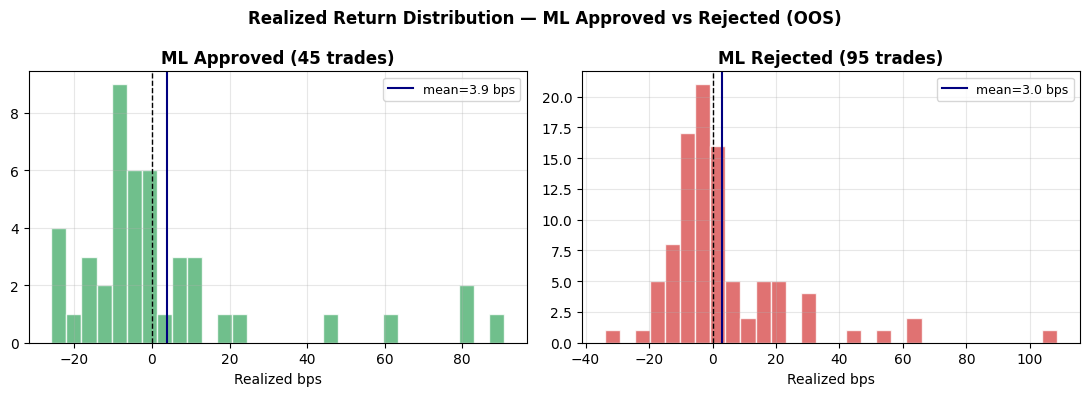

In [76]:
# Approved vs. rejected trade outcomes on OOS baseline events
oos_b2_baseline = baseline_b2[baseline_b2.index >= oos_start_ts].copy()
ml_pred_series  = pd.Series(y_pred, index=X_oos.index, name="ml_approved")
oos_b2_with_ml  = oos_b2_baseline.join(ml_pred_series, how="inner")

approved = oos_b2_with_ml[oos_b2_with_ml["ml_approved"] == 1]["realized_bps"].dropna()
rejected = oos_b2_with_ml[oos_b2_with_ml["ml_approved"] == 0]["realized_bps"].dropna()

print(f"OOS baseline events: {len(oos_b2_baseline)}")
print(f"  ML approved: {len(approved):3d}  |  win={( approved>0).mean()*100:.1f}%  avg={approved.mean():.2f} bps")
print(f"  ML rejected: {len(rejected):3d}  |  win={(rejected>0).mean()*100:.1f}%  avg={rejected.mean():.2f} bps")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (label, series, color) in zip(axes, [
    ("ML Approved", approved, "#4caf70"),
    ("ML Rejected", rejected, "#d94f4f"),
]):
    ax.hist(series, bins=30, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.axvline(series.mean(), color="navy", linewidth=1.5, linestyle="-", label=f"mean={series.mean():.1f} bps")
    ax.set_title(f"{label} ({len(series)} trades)", fontweight="bold")
    ax.set_xlabel("Realized bps")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle("Realized Return Distribution — ML Approved vs Rejected (OOS)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. SD-Filtered Events (Issue #6 — 10:30 Gate + Volatility Band)

Rebuild signal events with the updated `build_signal_frame` defaults:
- `session_start="10:30"` — ensures the 55-bar window is built on RTH data only  
- `std_low_pct=0.20, std_high_pct=0.80` — filters dead/illiquid and chaotic-volatility bars

In [77]:
filtered_sig = build_signal_frame(
    metrics_df,
    hit_ratio_threshold=HR_THRESH,
    spearman_threshold=SP_THRESH,
    # session_start="10:30" and std 20-80 percentile band applied by default
)
filtered_events = filtered_sig[filtered_sig["event_start"]].copy()
filtered_events["conviction_score"] = (
    volume_df["conviction_score"].reindex(filtered_events.index)
)

filtered_b2 = simulate_path_b2(metrics_df, filtered_events)

removed = len(baseline_events) - len(filtered_events)
print(f"Baseline events          : {len(baseline_events)}")
print(f"Filtered events          : {len(filtered_events)}  (removed {removed}, {removed/len(baseline_events)*100:.1f}%)")
print()
print("Filtered events — Path B2 exit")
print(f"  Win rate : {(filtered_b2['realized_bps']>0).mean()*100:.1f}%")
print(f"  Avg bps  : {filtered_b2['realized_bps'].mean():.2f}")
print(f"  Avg hold : {filtered_b2['hold_bars'].mean():.1f} bars")

Baseline events          : 466
Filtered events          : 17  (removed 449, 96.4%)

Filtered events — Path B2 exit
  Win rate : 17.6%
  Avg bps  : -5.20
  Avg hold : 7.3 bars


## 8. Position Sizing

**Flat sizing** — all approved trades use size=1.0 (1 unit).  
Simple, robust, and avoids overcomplicating with volatility or Kelly adjustments.  
Curve 4 uses flat sizing after ML filtering.

In [83]:
# Flat sizing: size=1.0 for all approved trades
print("Position sizing: Flat (size=1.0 for all ML-approved trades)")
print("Simple and robust — no adjustments for volatility or Kelly.")

Position sizing: Flat (size=1.0 for all ML-approved trades)
Simple and robust — no adjustments for volatility or Kelly.


## 9. Equity Curve Comparison — OOS Period

All four curves evaluated on events **after** the IS/OOS split timestamp.

| Curve | Signal | Exit | Sizing |
|---|---|---|---|
| 1 | Baseline (09:30, no SD filter) | Fixed 35-min hold | Flat |
| 2 | Baseline | Path B2 (K=7, −5 bps) | Flat |
| 3 | SD-filtered + 10:30 gate | Path B2 | Flat |
| 4 | SD-filtered + 10:30 gate + ML filter | Path B2 | Flat |

In [85]:
def equity_metrics(pnl: pd.Series) -> dict:
    clean = pnl.dropna()
    n     = len(clean)
    if n == 0:
        return {k: np.nan for k in
                ["n", "win%", "avg_bps", "total_bps", "max_dd_bps", "sharpe", "sortino", "calmar"]}
    cum    = clean.cumsum()
    dd     = cum - cum.cummax()
    max_dd = dd.min()
    total  = cum.iloc[-1]
    mu     = clean.mean()
    sigma  = clean.std(ddof=1) or 1e-9
    d_std  = clean[clean < 0].std(ddof=1) or 1e-9
    return {
        "n":         n,
        "win%":      round((clean > 0).mean() * 100, 1),
        "avg_bps":   round(mu, 2),
        "total_bps": round(total, 1),
        "max_dd_bps":round(max_dd, 1),
        "sharpe":    round(mu / sigma * n**0.5, 3),
        "sortino":   round(mu / d_std * n**0.5, 3),
        "calmar":    round(total / abs(max_dd), 3) if max_dd < 0 else float("inf"),
    }


# ── Curve 1: baseline fixed hold ───────────────────────────────────────────
oos_baseline  = baseline_events[baseline_events.index >= oos_start_ts]
c1_pnl = (
    oos_baseline["nq_fwd_35"] * oos_baseline["regime_dir"] * 10_000
).dropna()

# ── Curve 2: baseline + Path B2 flat ───────────────────────────────────────
c2_pnl = baseline_b2.loc[baseline_b2.index >= oos_start_ts, "realized_bps"].dropna()

# ── Curve 3: filtered + Path B2 flat ───────────────────────────────────────
c3_pnl = oos_filtered_b2["realized_bps"].dropna()

# ── Curve 4: filtered + ML filter + flat sizing ─────────────────────────────
# Apply ML classifier to OOS filtered events
oos_filt_feats = build_ml_features(oos_filtered_events, volume_df)
oos_filt_feats = oos_filt_feats.reindex(columns=FEATURE_COLS).dropna()
X_c4      = scaler.transform(oos_filt_feats[FEATURE_COLS])
c4_pred   = clf.predict(X_c4)
approved_idx = oos_filt_feats.index[c4_pred == 1]

c4_pnl = oos_filtered_b2.loc[approved_idx, "realized_bps"].dropna()

print(f"OOS events per curve — C1:{len(c1_pnl)}  C2:{len(c2_pnl)}  C3:{len(c3_pnl)}  C4:{len(c4_pnl)}")

OOS events per curve — C1:140  C2:140  C3:4  C4:0


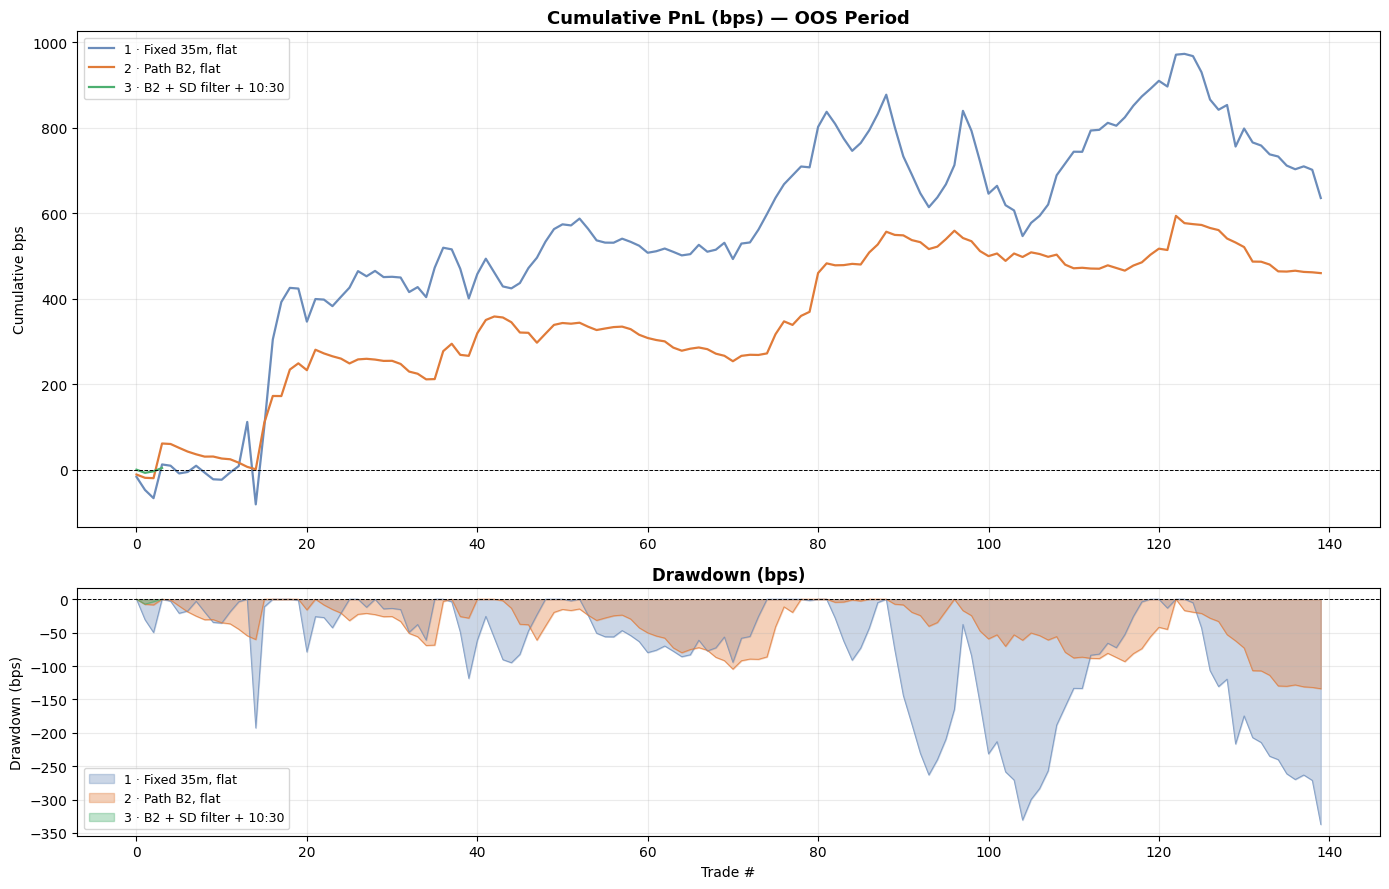


Summary Metrics — OOS Period
                                    n  win%  avg_bps  total_bps  max_dd_bps  sharpe  sortino  calmar
1 · Fixed 35m, flat            140.00 52.10     4.54     635.60     -337.20    1.15     1.73    1.89
2 · Path B2, flat              140.00 38.60     3.29     459.90     -133.90    1.74     5.69    3.43
3 · B2 + SD filter + 10:30       4.00 75.00     1.04       4.20       -7.30    0.33      NaN    0.57
4 · B2 + SD + ML + flat sizing    NaN   NaN      NaN        NaN         NaN     NaN      NaN     NaN


In [86]:
curves = {
    "1 · Fixed 35m, flat":              c1_pnl,
    "2 · Path B2, flat":                c2_pnl,
    "3 · B2 + SD filter + 10:30":       c3_pnl,
    "4 · B2 + SD + ML + flat sizing":    c4_pnl,
}
colors = ["#6b8cba", "#e07b39", "#4caf70", "#d94f4f"]

fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(14, 9),
                                    gridspec_kw={"height_ratios": [2, 1]})

for (label, pnl), color in zip(curves.items(), colors):
    if pnl.empty:
        continue
    cum = pnl.reset_index(drop=True).cumsum()
    dd  = cum - cum.cummax()
    ax_eq.plot(cum.index, cum.values, label=label, color=color, linewidth=1.6)
    ax_dd.fill_between(dd.index, dd.values, 0, alpha=0.35, color=color, label=label)
    ax_dd.plot(dd.index, dd.values, color=color, linewidth=0.7, alpha=0.7)

ax_eq.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax_eq.set_title("Cumulative PnL (bps) — OOS Period", fontsize=13, fontweight="bold")
ax_eq.set_ylabel("Cumulative bps")
ax_eq.legend(fontsize=9, loc="upper left")
ax_eq.grid(alpha=0.25)
ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))

ax_dd.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax_dd.set_title("Drawdown (bps)", fontsize=12, fontweight="bold")
ax_dd.set_ylabel("Drawdown (bps)")
ax_dd.set_xlabel("Trade #")
ax_dd.legend(fontsize=9, loc="lower left")
ax_dd.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame(
    {name: equity_metrics(pnl) for name, pnl in curves.items()}
).T

print("\nSummary Metrics — OOS Period")
print("=" * 80)
print(summary.to_string(float_format="{:.2f}".format))